# Predicting Fish Weight Using Linear Regression

**Course:** AIT 525

**Assignment:** Predict a Numerical Value Using Regression

**By:** Yashu Lanki

**Date:** 6 September, 2026

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline
sns.set_theme()

In [2]:
df = pd.read_csv("Fish.csv")
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


## 2. Dataset Exploration

_Explore the dataset, focusing on key features like Length, Height, Width, and Weight._

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    str    
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), str(1)
memory usage: 8.8 KB


In [4]:
df.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


In [5]:
weight_df = df[df['Weight'] <= 0]
weight_df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
40,Roach,0.0,19.0,20.5,22.8,6.4752,3.3516


In [6]:
length_df = df[(df['Length1'] < 0) | (df['Length2'] < 0) | (df['Length3'] < 0) | (df['Height'] < 0) | (df['Width'] < 0)]
length_df

,Species,Weight,Length1,Length2,Length3,Height,Width


In [7]:
df = df[df['Weight'] > 0].reset_index(drop=True)
df.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,400.847468,26.293038,28.465823,31.280380,8.986790,4.424232
std,357.697796,10.011427,10.731707,11.627605,4.295191,1.689010
min,5.900000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,121.250000,19.150000,21.000000,23.200000,5.940600,3.398650
50%,281.500000,25.300000,27.400000,29.700000,7.789000,4.277050
75%,650.000000,32.700000,35.750000,39.675000,12.371850,5.586750
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


In [8]:
corr = df.corr(numeric_only=True)
corr

,Weight,Length1,Length2,Length3,Height,Width
Weight,1.000000,0.915719,0.918603,0.923090,0.723857,0.886654
Length1,0.915719,1.000000,0.999516,0.992004,0.624409,0.866684
Length2,0.918603,0.999516,1.000000,0.994083,0.639503,0.873201
Length3,0.923090,0.992004,0.994083,1.000000,0.702655,0.878189
Height,0.723857,0.624409,0.639503,0.702655,1.000000,0.792401
Width,0.886654,0.866684,0.873201,0.878189,0.792401,1.000000


<Axes: >

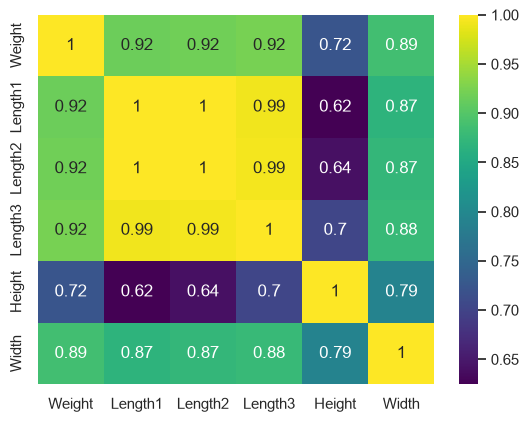

In [9]:
sns.heatmap(corr, annot=True, cmap='viridis')

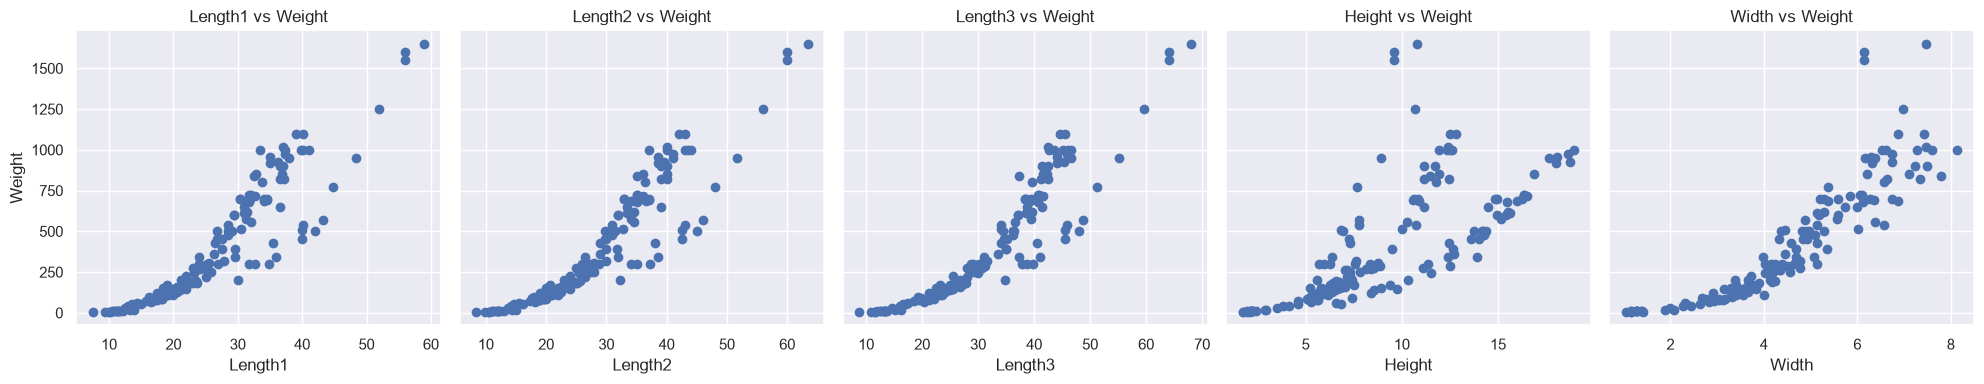

In [10]:
features = ['Length1', 'Length2', 'Length3', 'Height', 'Width']

fig, axes = plt.subplots(1, len(features), figsize=(20, 4), sharey=True)

for ax, col in zip(axes, features):
    ax.scatter(df[col], df['Weight'])
    ax.set_title(f'{col} vs Weight')
    ax.set_xlabel(col)

axes[0].set_ylabel('Weight')

plt.tight_layout()
plt.show()

## 3. Mathematical Model Design

_Describe the mathematical formula for linear regression, showing how input features combine to predict fish weight. Explain the role of parameters (coefficients and intercept) and how they're optimized through gradient descent._

For our case: $${y} = \beta_0 + \beta_1(x_1) + \beta_2(x_2) + \beta_3(x_3)
   + \epsilon$$

 - $y$ - the target variable which is weight.
 - $\beta_0$ (intercept) — the baseline predicted weight when all features are 0 (not physically meaningful here, but mathematically necessary).
 - $\beta_1$, $\beta_2$, $\beta_3$ - are the slopes for each predictor where each one tells you how much y changes when that particular x increases by one unit
 - $x_1$, $x_2$, $x_3$ - are your different predictor variables
 - $\epsilon$ - error variable between the estimated vs the actual value

- Define a cost function, typically Mean Squared Error: $J(\beta) = \frac{1}{n}\sum (y_i - \hat{y}_i)^2$
- Gradient descent iteratively updates each $\beta$ in the direction that reduces $J(\beta)$, using a learning rate to control step size, until it converges.
- Contrast this with the closed-form/normal equation solution (LinearRegression), which solves for $\beta$ directly without iteration — this sets up why you'll
- compare LinearRegression (closed-form) vs. SGDRegressor (gradient descent) in section 4.

## 4. Model Implementation

_Implement a linear regression model that predicts fish weight based on the physical characteristics of the fish. Identify factors that impact model performance._

### 4.1 Baseline Model

In [11]:
feature_cols = ['Length1', 'Length2', 'Length3', 'Height', 'Width']
X = df[feature_cols]
y = df['Weight']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
regressor = LinearRegression()
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

### 4.2 Optimization (Gradient Descent)

_Apply optimization techniques, such as gradient descent, to improve model predictions and outline how these methods enhance the model's accuracy and efficiency._

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sgd_model = SGDRegressor(max_iter=1000, random_state=42)
sgd_model.fit(X_train_scaled, y_train)

y_pred_sgd = sgd_model.predict(X_test_scaled)

mse_sgd = mean_squared_error(y_test, y_pred_sgd)
r2_sgd = r2_score(y_test, y_pred_sgd)

## 5. Performance Evaluation

_Calculate performance metrics (e.g., MSE, R-squared) for the regression model. Explain the significance of these metrics. Compare the initial model's performance to the optimized model and discuss improvements._

In [13]:
print('Mean Squared Error: ', round(mse,3))
print('R2 Score: ', round(r2,3))
print('\n')
print('SGD Mean Squared Error: ', round(mse_sgd,3))
print('SGD R2 Score: ', round(r2_sgd,3))

Mean Squared Error:  12829.16
R2 Score:  0.904


SGD Mean Squared Error:  13814.56
SGD R2 Score:  0.897


Metric significance. MSE measures the average squared prediction error in grams²; taking its square root gives a more interpretable number in the original units —
  √12829.16 ≈ 113g for the baseline and √13814.56 ≈ 118g for SGD, meaning both models are typically off by roughly 113–118 grams per fish. R² measures the proportion
  of variance in Weight explained by the model, on a 0–1 scale; both models explain about 90% of the variance in fish weight from the length/height/width measurements
  alone.

  Comparing the models. The baseline LinearRegression (closed-form/normal equation) slightly outperforms the SGDRegressor (gradient descent) — MSE 12829 vs. 13815, R²
  0.904 vs. 0.897. This is expected: the closed-form solution computes the exact optimal coefficients in one step, while SGD approximates that same solution
  iteratively and only converges to near-optimal, especially with a fixed number of iterations (max_iter=1000) and a basic learning-rate schedule. The gap here is
  small (~1 percentage point of R²), which suggests SGD converged close to the true minimum.

  Discussion / improvements. The two models producing nearly identical results here is actually a good sign: it confirms SGDRegressor is correctly approximating the
  same underlying linear relationship, just through a different optimization method. To close the small remaining gap, you could increase max_iter, tune the learning
  rate (eta0/learning_rate schedule), or lower tol so SGD keeps iterating longer before stopping. Both models still leave ~10% of weight variance unexplained, likely
  due to factors not captured by these 5 measurements — most notably Species, since different species have different weight-to-length ratios (visible in your section 2
  scatterplots) but wasn't included as a feature.

## 6. Real-World Applications

_Explore how regression models are employed in real-world business scenarios (resource allocation, customer retention, trend prediction, etc.)._

Regression models like the one built above generalize far beyond predicting fish weight — anywhere a business needs to estimate a numerical outcome from measurable inputs, linear regression (or its gradient-descent variant) is a natural starting point:

- **Resource allocation.** A retailer can regress warehouse staffing needs or inventory levels on features like historical order volume, seasonality, and store size — similar to how we predicted `Weight` from physical measurements, a supply chain team predicts demand from observable proxies so they can allocate stock and labor before it's needed rather than reacting after the fact.

- **Customer retention.** Subscription businesses regress customer lifetime value or churn risk on usage frequency, support ticket counts, and tenure. The coefficients play the same role as our `Length`/`Height`/`Width` coefficients: they quantify how much each behavior drives the outcome, letting retention teams prioritize the highest-impact interventions (e.g., reaching out to customers whose usage is dropping fastest).

- **Trend and demand prediction.** Regression is core to sales forecasting — predicting next quarter's revenue from ad spend, price changes, and macroeconomic indicators. Just as we compared a closed-form solution to gradient descent here, large-scale forecasting systems favor `SGDRegressor`-style optimization because closed-form solutions become computationally impractical once the number of features or rows grows into the millions.

- **Pricing and valuation.** Real estate and e-commerce platforms regress price on measurable attributes (square footage, location, condition) in essentially the same structure as this notebook — a handful of physical/observable features predicting a single numeric target.

The common thread: regression is most useful in business settings where the input features are cheap/easy to measure but the target variable is expensive, delayed, or impossible to measure directly — exactly the situation here, where a fish's weight is harder to obtain at scale than its length, height, and width.

## 7. Conclusion

This project set out to predict fish weight from physical measurements — `Length1`, `Length2`, `Length3`, `Height`, and `Width` — using linear regression. After cleaning the data (dropping one biologically impossible zero-weight row and confirming no negative measurements existed), the exploration step showed all five features are strongly correlated with `Weight` (0.72–0.92), with `Length3` the strongest single predictor.

Both models tested — a closed-form `LinearRegression` baseline and an iterative `SGDRegressor` — explained roughly 90% of the variance in weight (R² of 0.904 and 0.897, respectively), with typical prediction errors around 113–118 grams. The near-identical performance confirms that gradient descent successfully approximates the same underlying linear relationship that the normal equation solves for directly, validating both the mathematical model from section 3 and its optimization in section 4.2.

The main limitation is the dataset itself: only 158 usable rows spanning 7 species, and `Species` was deliberately excluded as a feature even though section 2's scatterplots show species clearly cluster at different weight-to-length ratios. A natural next step would be one-hot encoding `Species` and testing whether it closes the remaining ~10% gap in explained variance — but as built, the model already demonstrates that a small set of easy-to-measure physical features can substitute for a much harder-to-measure target, which is the core value proposition of regression discussed in section 6.

## References

- **Dataset:** Vipul Rathod, *Fish Market Dataset*, Kaggle — https://www.kaggle.com/datasets/vipullrathod/fish-market — source of `Fish.csv`, used in section 2 for exploration and sections 4–5 for model training/evaluation.
- **scikit-learn documentation** — https://scikit-learn.org/stable/ — reference for `LinearRegression` and `SGDRegressor` (section 4), `StandardScaler` (section 4.2), `train_test_split`, and `mean_squared_error`/`r2_score` (section 5).
- **pandas documentation** — https://pandas.pydata.org/docs/ — reference for `DataFrame.describe()`, `DataFrame.corr()`, and boolean filtering used throughout section 2.
- **seaborn documentation** — https://seaborn.pydata.org/ — reference for `sns.heatmap()` (section 2) used to visualize the correlation matrix.
- **matplotlib documentation** — https://matplotlib.org/stable/ — reference for the scatter plots and subplot grids in section 2.
- **Linear regression (concept)** — https://en.wikipedia.org/wiki/Linear_regression — background for the model formula and parameter interpretation in section 3.
- **Ordinary least squares / normal equation** — https://en.wikipedia.org/wiki/Ordinary_least_squares — the closed-form solution used by `LinearRegression` in section 4.1, contrasted with gradient descent in section 3 and 4.2.
- **Gradient descent** — https://en.wikipedia.org/wiki/Gradient_descent — background for the iterative optimization method behind `SGDRegressor` in section 4.2.
- **Mean squared error (MSE)** — https://en.wikipedia.org/wiki/Mean_squared_error — definition and interpretation used as the evaluation metric in section 5.
- **Coefficient of determination (R²)** — https://en.wikipedia.org/wiki/Coefficient_of_determination — definition and interpretation used as the second evaluation metric in section 5.